<a href="https://www.kaggle.com/code/ivanocampos/california-housing?scriptVersionId=351884080" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Librerías para manipulación, visualización y carga portable de datos.
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Usamos una ruta para Kaggle y otra para ejecución local en VS Code.
kaggle_path = '/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv'
local_path = 'housing.csv'

# Cargamos el dataset desde la ruta que exista en el entorno actual.
if os.path.exists(kaggle_path):
    df = pd.read_csv(kaggle_path)
    print("Cargado desde el entorno de Kaggle")
elif os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print("Cargado desde el entorno local (VS Code)")
else:
    raise FileNotFoundError("No se encontro el archivo 'housing.csv' en ninguna de las rutas.")

# Vista inicial: permite comprobar que las columnas se cargaron correctamente.
df.head()

Cargado desde el entorno de Kaggle


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
# Revisamos dimensiones, tipos de datos y valores no nulos por variable.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
# Resumen estadístico de las columnas numéricas para detectar escalas y extremos.
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
# Contamos valores faltantes antes de aplicar cualquier limpieza.
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
# Imputamos los valores nulos con la mediana
mediana_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(mediana_bedrooms)

# Verificamos que ya no existan nulos
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [6]:
# Revisamos la frecuencia de cada categoría de cercanía al océano.
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
# Convertimos la variable categórica en columnas binarias para futuros modelos.
# Conservamos todas las categorías para que la transformación sea fácil de inspeccionar.
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [8]:
# El dataset limita el precio máximo a 500001; contamos cuántas observaciones están cappeadas.
(df['median_house_value'] == 500001).sum()

np.int64(965)

In [9]:
# Creamos una bandera para identificar registros afectados por ese límite artificial.
df['is_capped'] = df['median_house_value'] == 500001

# Verificación rápida
df['is_capped'].value_counts()

is_capped
False    19675
True       965
Name: count, dtype: int64

In [10]:
# Confirmamos que el dataframe final no conserva valores faltantes.
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
is_capped             0
dtype: int64

In [11]:
# Verificamos los tipos tras el preprocesamiento y la creación de variables auxiliares.
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
is_capped                bool
dtype: object

## Análisis simple: distribución y comparación de precios

En esta sección examinamos cómo se distribuyen las variables y comparamos el precio mediano de las viviendas entre categorías de cercanía al océano. Los histogramas permiten detectar sesgos y valores extremos; los boxplots y violinplots muestran diferencias de precio y dispersión entre zonas.

También se repite la comparación sin los registros cuyo precio está limitado a `$500,001`, para evitar que ese tope del dataset distorsione la lectura.

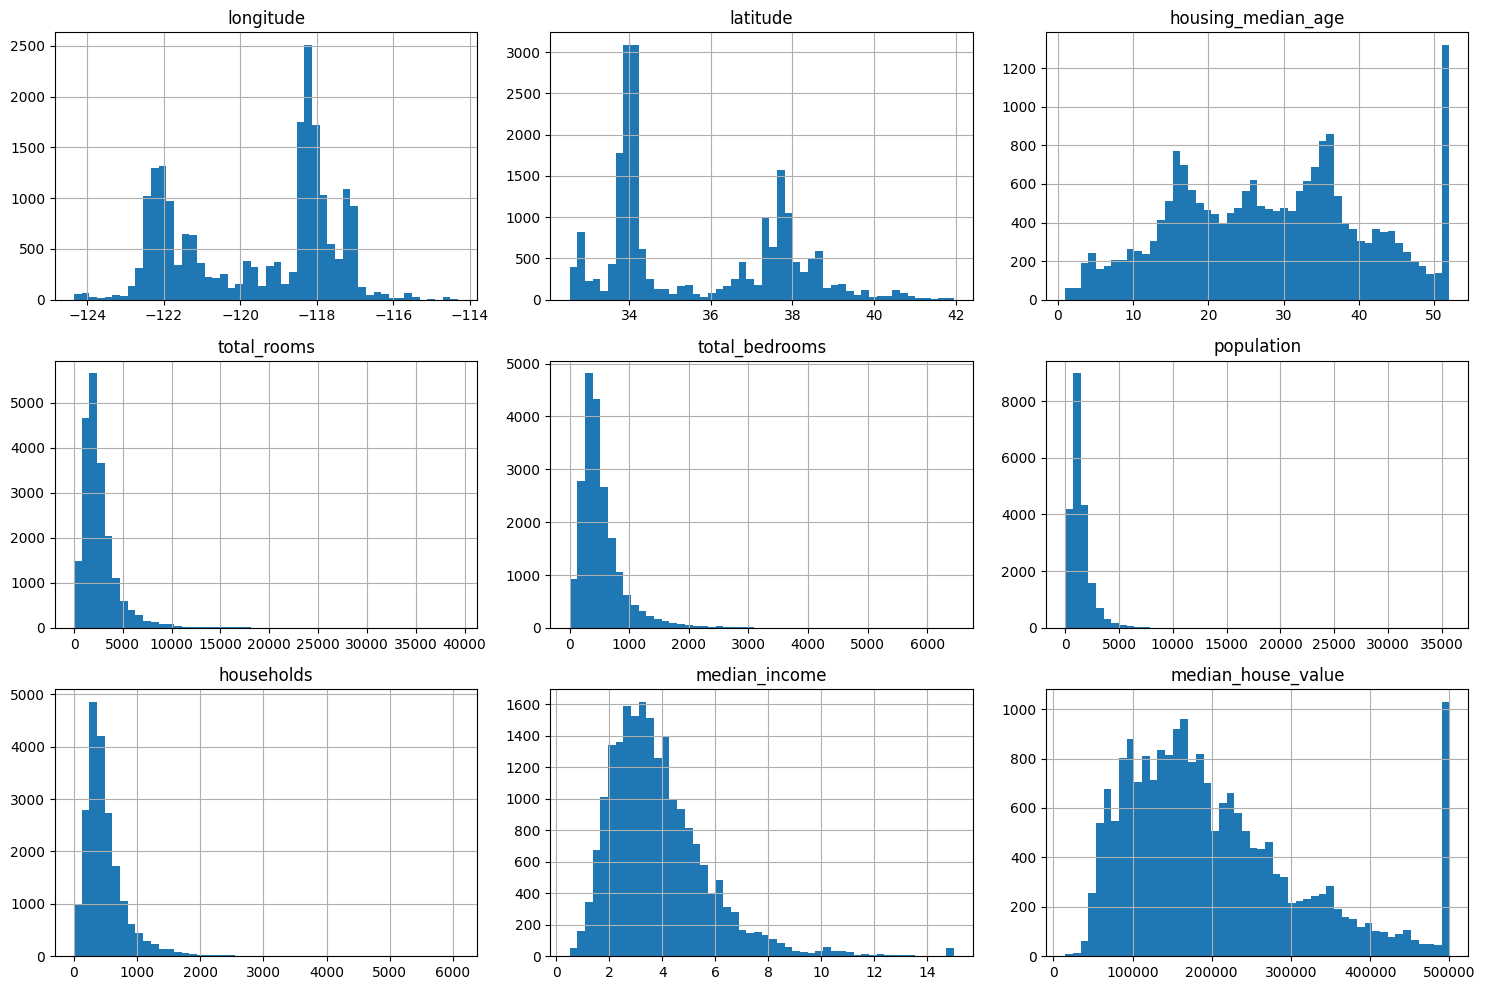

In [12]:
# Histogramas de todas las variables numéricas: muestran forma, sesgo y posibles valores extremos.
df.hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()

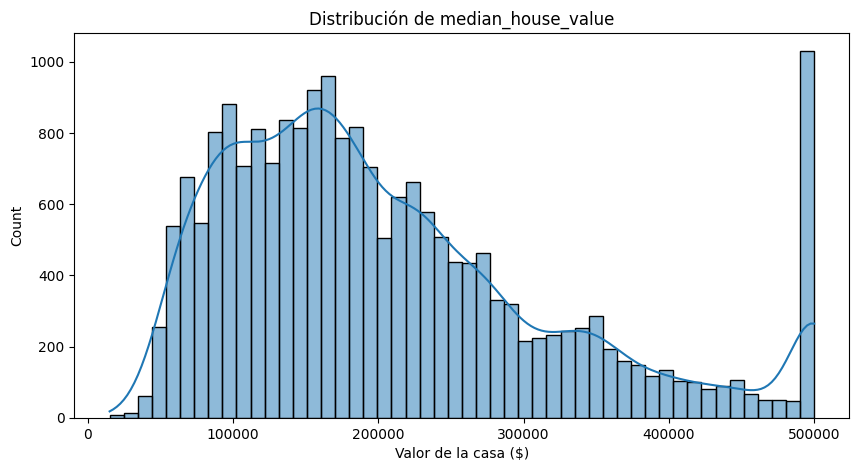

In [13]:
# Analizamos en detalle la distribución de la variable objetivo: el precio mediano de la vivienda.
plt.figure(figsize=(10, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Distribución de median_house_value')
plt.xlabel('Valor de la casa ($)')
plt.show()

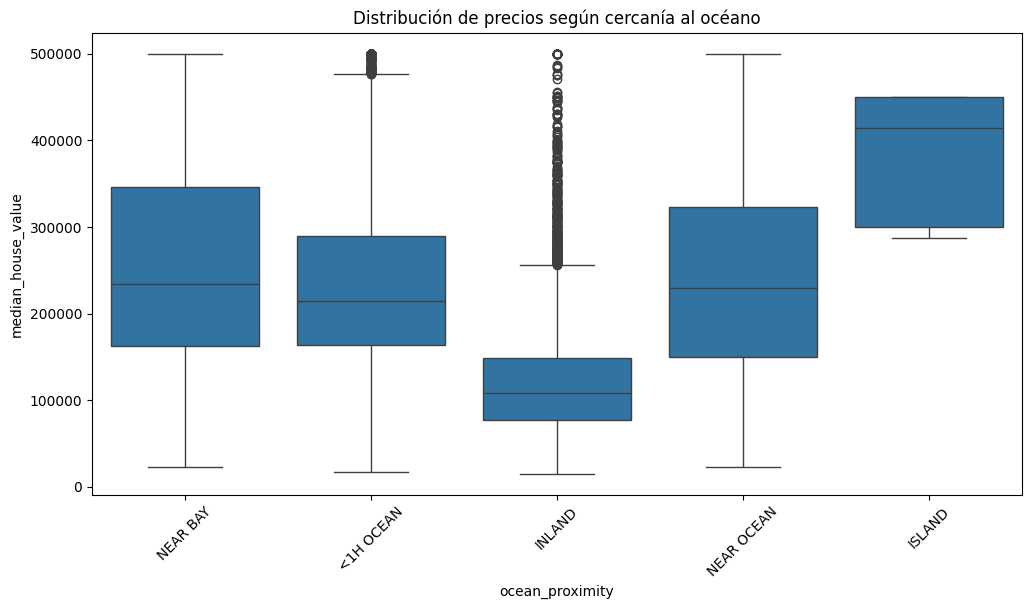

In [14]:
# Comparamos precios entre categorías de cercanía al océano mediante un boxplot.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value')
plt.title('Distribución de precios según cercanía al océano')
plt.xticks(rotation=45)
plt.show()

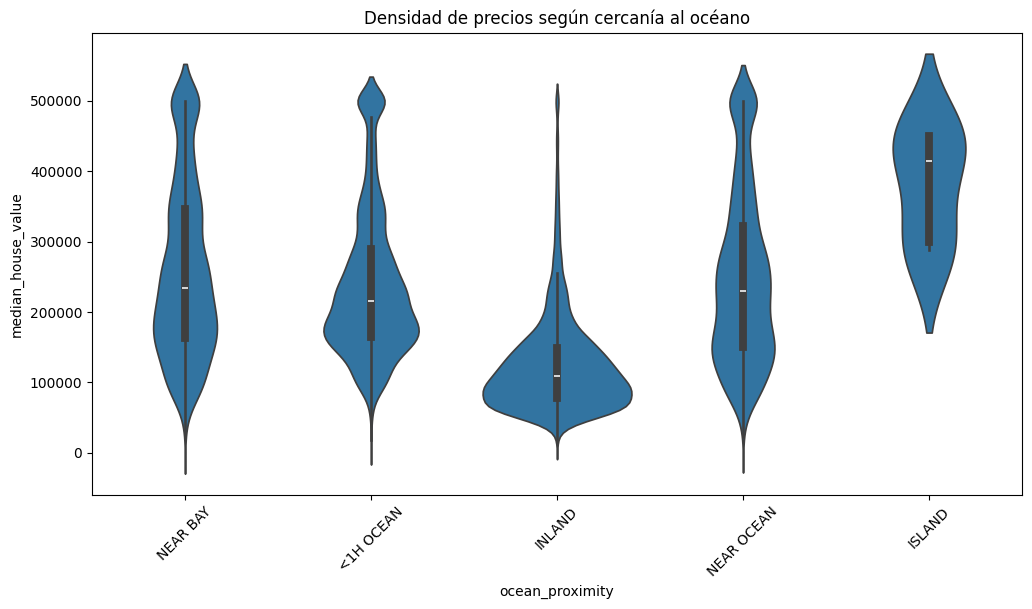

In [15]:
# El violinplot añade la densidad de la distribución a la comparación por categoría.
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='ocean_proximity', y='median_house_value')
plt.title('Densidad de precios según cercanía al océano')
plt.xticks(rotation=45)
plt.show()

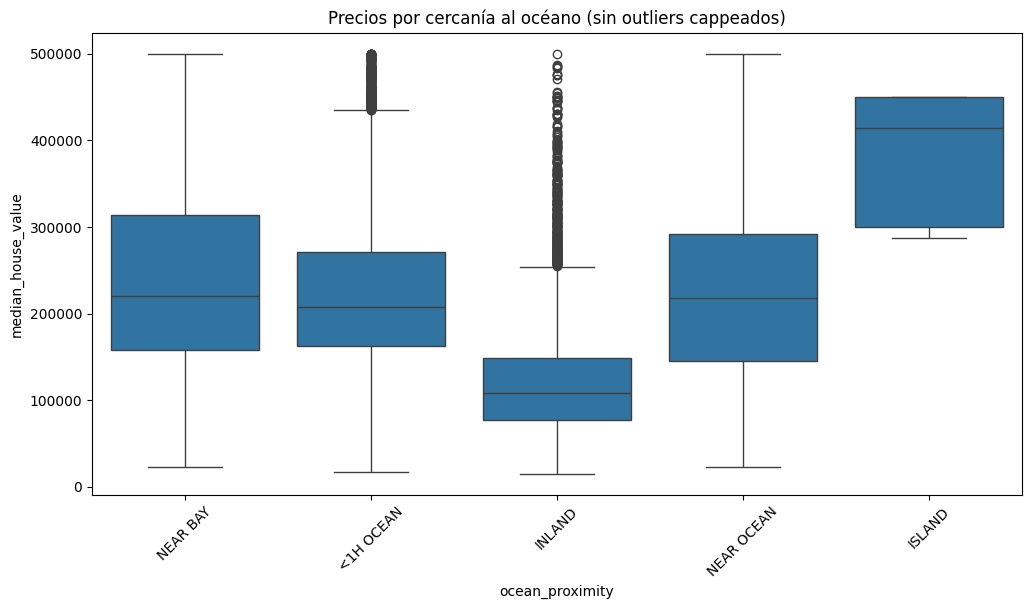

In [16]:
# Excluimos precios cappeados para comprobar si el límite afecta la comparación entre zonas.
df_sin_cap = df[~df['is_capped']]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_sin_cap, x='ocean_proximity', y='median_house_value')
plt.title('Precios por cercanía al océano (sin outliers cappeados)')
plt.xticks(rotation=45)
plt.show()

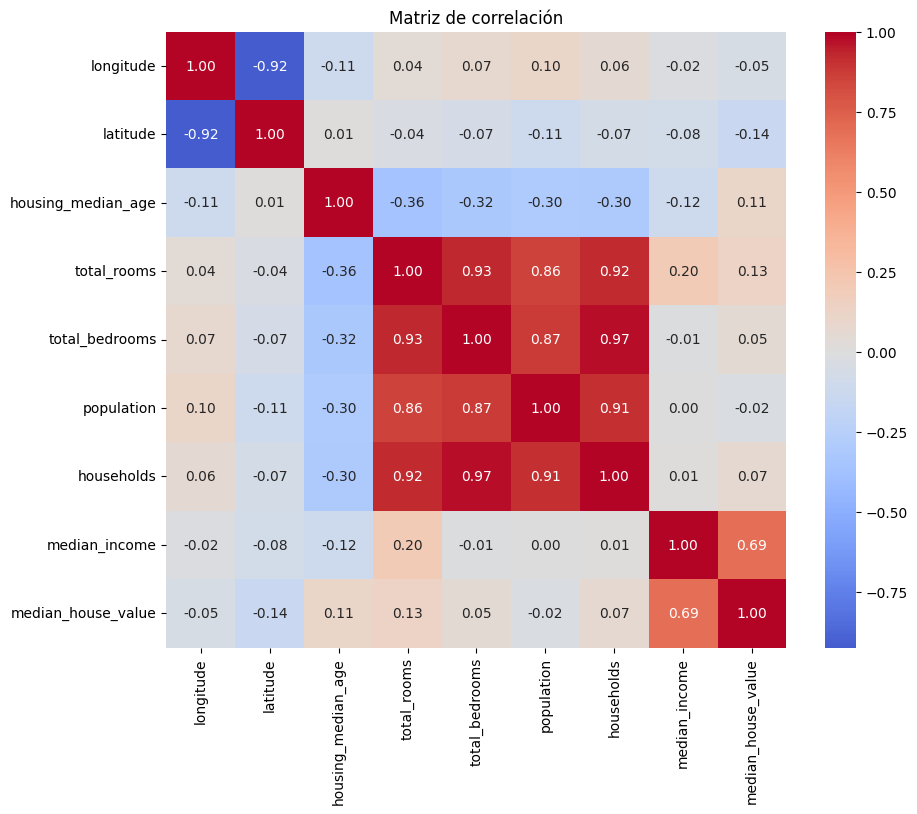

In [17]:
# Calculamos correlaciones solo entre variables numéricas; las categorías requieren otro tratamiento.
cols_numericas = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[cols_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

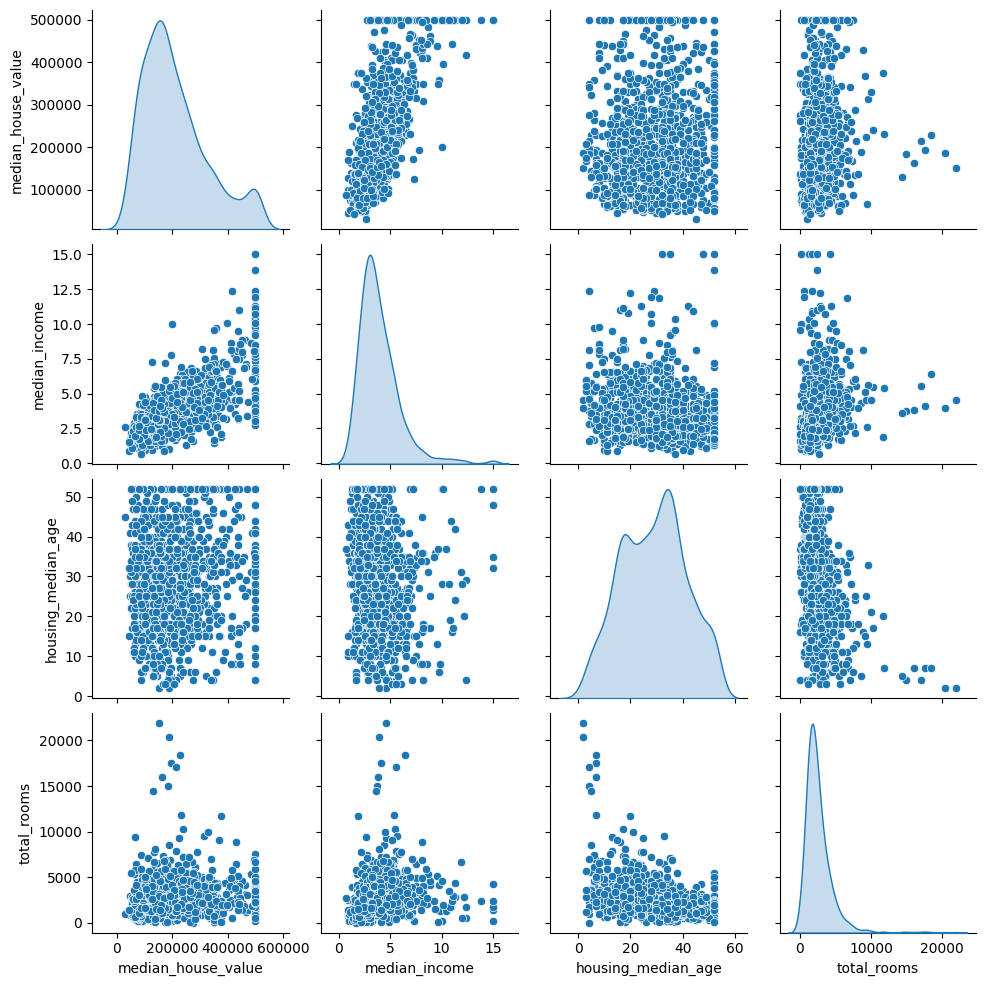

In [18]:
# Usamos una muestra reproducible para que el pairplot sea legible y rápido de generar.
df_sample = df.sample(1000, random_state=42)

# Truco 2: elegir las variables más relevantes en vez de todas
cols_interes = ['median_house_value', 'median_income', 'housing_median_age', 'total_rooms']

sns.pairplot(df_sample[cols_interes], diag_kind='kde')
plt.show()

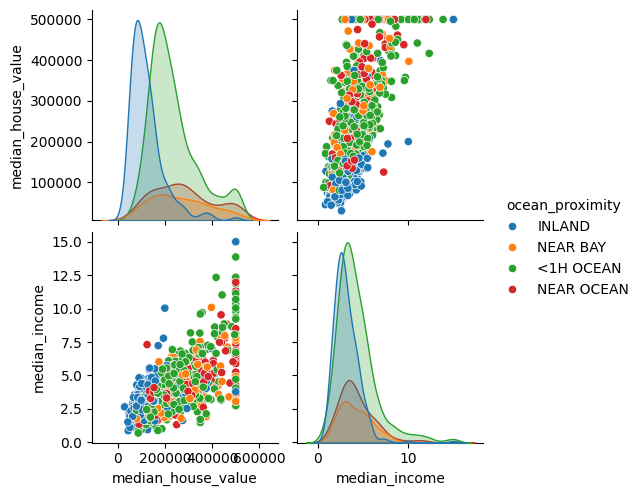

In [19]:
# Repetimos el pairplot y coloreamos los puntos por cercanía al océano para buscar patrones.
cols_interes_cat = ['median_house_value', 'median_income', 'ocean_proximity']
sns.pairplot(df_sample[cols_interes_cat], hue='ocean_proximity', diag_kind='kde')
plt.show()

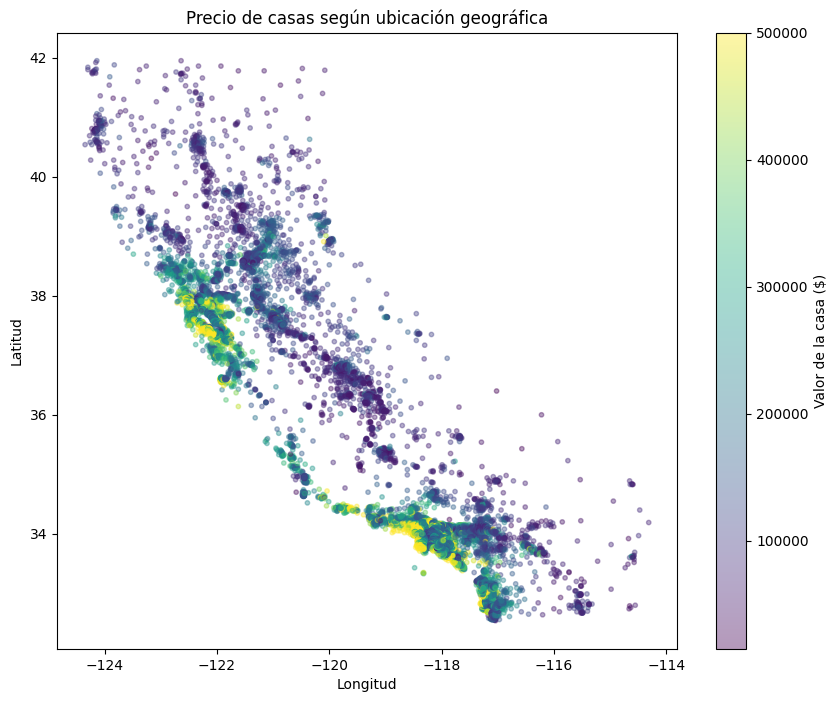

In [20]:
# Visualización geográfica: el color representa el precio y revela patrones espaciales.
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['longitude'], df['latitude'], 
                       c=df['median_house_value'], 
                       cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Valor de la casa ($)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Precio de casas según ubicación geográfica')
plt.show()

## Análisis complejo: relaciones, ubicación e ingeniería de variables

Ahora buscamos relaciones entre varias variables a la vez. La matriz de correlación y los pairplots ayudan a identificar variables potencialmente asociadas al precio; el gráfico geográfico permite observar patrones espaciales.

Por último, construimos indicadores por hogar (`rooms_per_household`, `bedrooms_per_room` y `population_per_household`). Estas variables relativas suelen describir mejor las características de una zona que los conteos absolutos y pueden ser útiles en un modelo predictivo posterior.

In [21]:
# Creamos ratios más interpretables que los conteos absolutos para el análisis posterior.
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

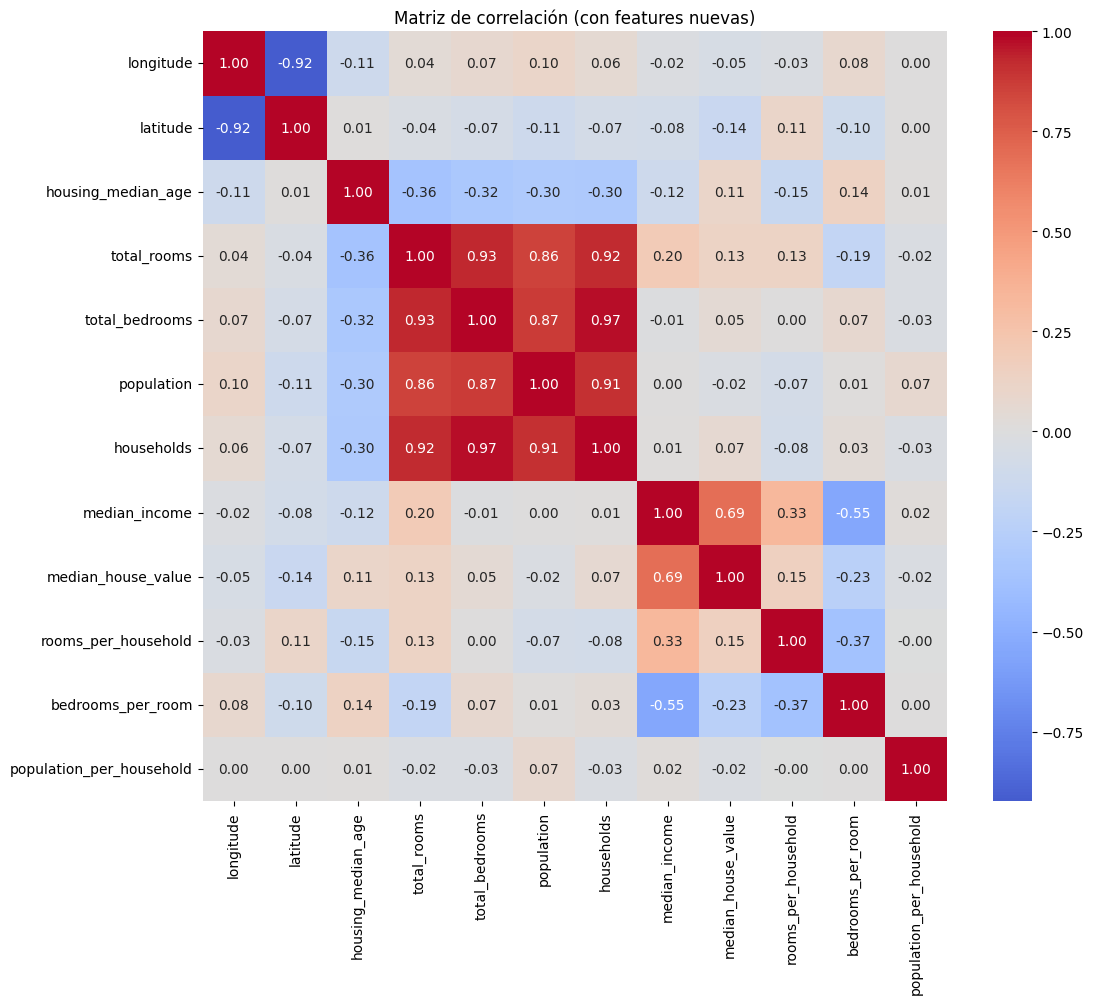

In [22]:
# Recalculamos la matriz para medir cómo se relacionan las variables creadas con el precio.
cols_numericas = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[cols_numericas].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación (con features nuevas)')
plt.show()

## Conclusiones y hallazgos

- `median_income` suele presentar una relación positiva importante con `median_house_value`; es una variable clave para profundizar en un modelo de precios.
- La cercanía al océano muestra diferencias en la distribución de precios. Conviene comparar medianas y dispersión, no solo promedios, porque existen valores extremos y el precio máximo está limitado en el dataset.
- La ubicación geográfica revela agrupaciones de precios: longitud y latitud contienen información relevante del mercado inmobiliario.
- Las variables derivadas por hogar permiten evaluar tamaño y densidad de las viviendas con una escala comparable entre distritos.

**Siguiente paso sugerido:** usar las variables numéricas y la codificación de `ocean_proximity` para construir un modelo base de regresión y evaluar su capacidad para predecir el precio mediano.